In [1]:
from s3_dataset_index import parse_s3_dataset

BASE_PATH = "s3://aind-benchmark-data/mesoscale-anatomy-cell-detection/train/"
training_sets = [
    "training_set_02032024",
    "training_set_2025_02_01",
    "training_set_2025_10_20",
    "training_set_2026_01_09",
]
training_sets_points = {}

for ts in training_sets:
    dataset_path = f"{BASE_PATH}{ts}/"
    dataset_index = parse_s3_dataset(
        dataset_path
    )
    training_sets_points[ts] = {
        "base_path": dataset_path,
        "dataset_index": dataset_index
    }
    print(f"Dataset index for {ts}: Datasets {len(dataset_index.keys())}")


Dataset index for training_set_02032024: Datasets 16
Dataset index for training_set_2025_02_01: Datasets 5
Dataset index for training_set_2025_10_20: Datasets 3
Dataset index for training_set_2026_01_09: Datasets 3


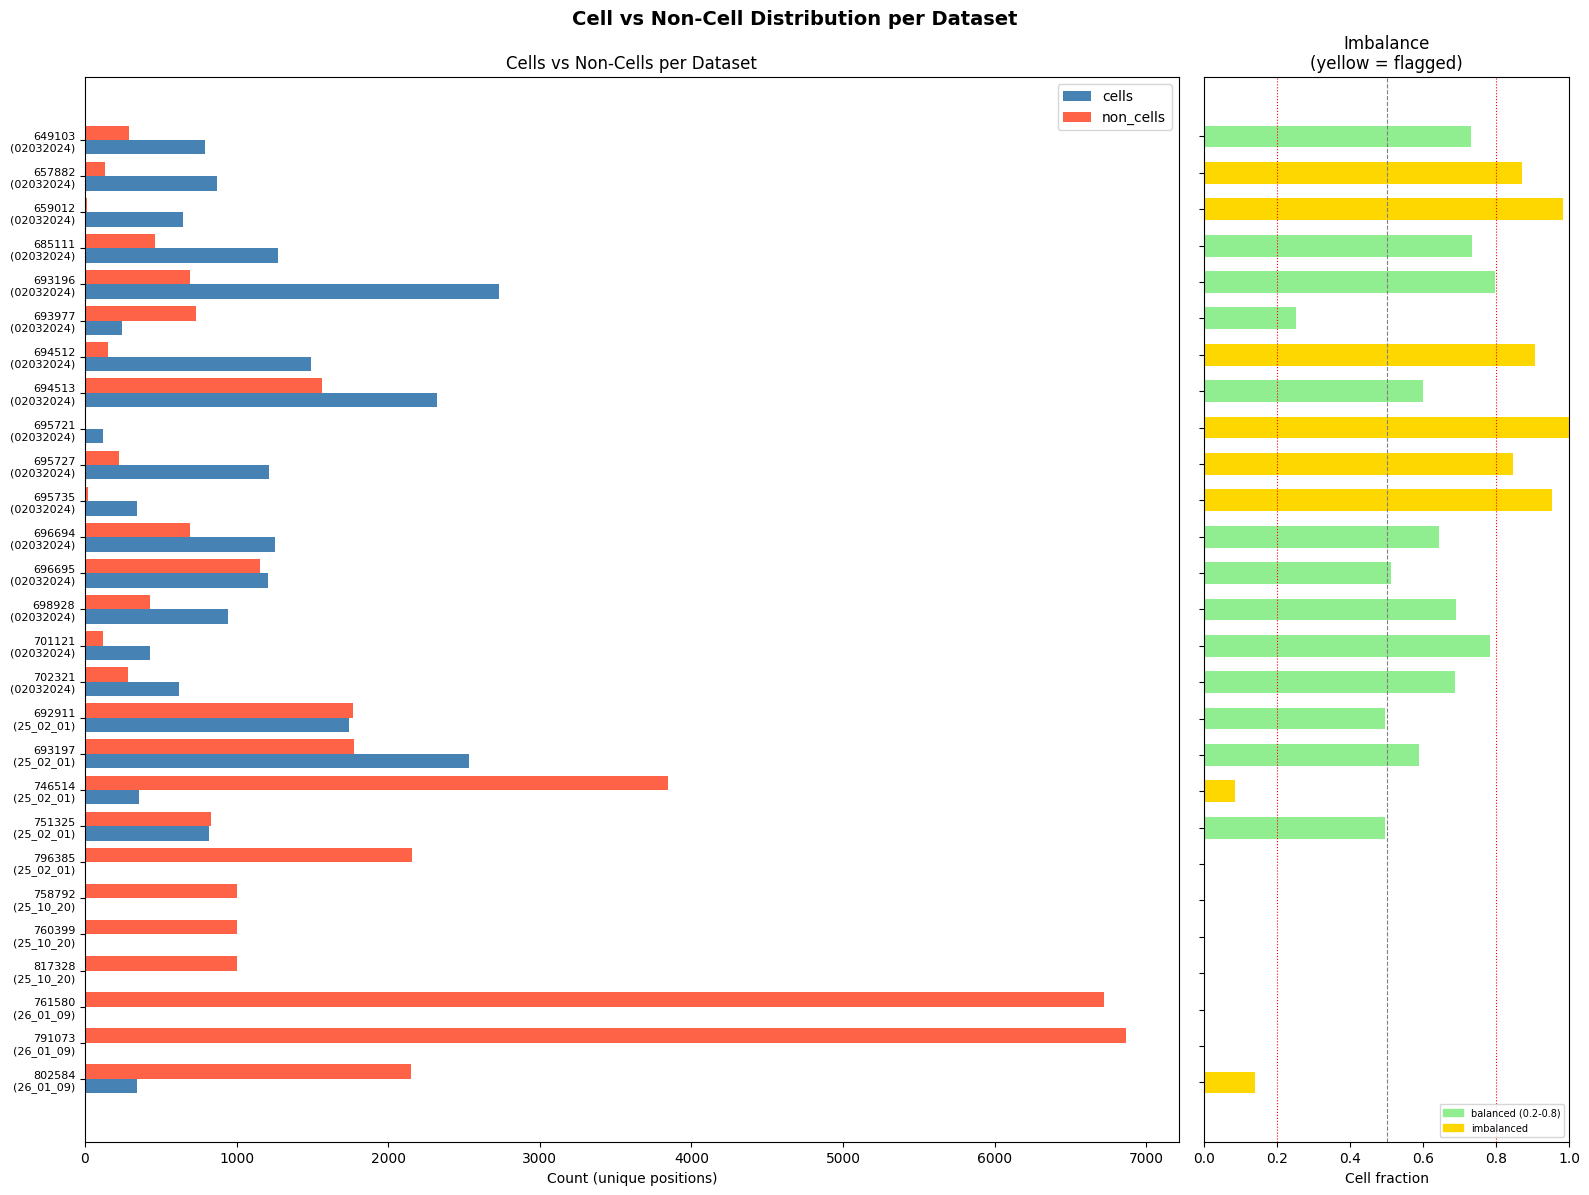

Flagged datasets: 14 / 27
           training_set dataset_id  n_cells  n_non_cells  cell_ratio
  training_set_02032024     657882      868          130    0.869739
  training_set_02032024     659012      649           11    0.983333
  training_set_02032024     694512     1493          153    0.907047
  training_set_02032024     695721      116            0    1.000000
  training_set_02032024     695727     1214          222    0.845404
  training_set_02032024     695735      343           17    0.952778
training_set_2025_02_01     746514      356         3843    0.084782
training_set_2025_02_01     796385        0         2160    0.000000
training_set_2025_10_20     758792        0         1000    0.000000
training_set_2025_10_20     760399        0         1000    0.000000
training_set_2025_10_20     817328        0         1000    0.000000
training_set_2026_01_09     761580        0         6724    0.000000
training_set_2026_01_09     791073        0         6869    0.000000
training

In [2]:
%matplotlib inline
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Aggregate unique positions per dataset ID across all channel folders
rows = []
for ts, ts_data in training_sets_points.items():
    for dataset_id, channels in ts_data["dataset_index"].items():
        all_cells = set()
        all_non_cells = set()
        for ch_data in channels.values():
            all_cells.update(ch_data["cells"])
            all_non_cells.update(ch_data["non_cells"])
        rows.append({
            "training_set": ts,
            "dataset_id": dataset_id,
            "n_cells": len(all_cells),
            "n_non_cells": len(all_non_cells),
        })

df = pd.DataFrame(rows).sort_values(["training_set", "dataset_id"]).reset_index(drop=True)
df["total"] = df["n_cells"] + df["n_non_cells"]
df["cell_ratio"] = df["n_cells"] / df["total"].replace(0, np.nan)
df["label"] = df["dataset_id"] + "\n(" + df["training_set"].str[-8:] + ")"

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df) * 0.45)),
                         gridspec_kw={"width_ratios": [3, 1]})
fig.suptitle("Cell vs Non-Cell Distribution per Dataset", fontsize=14, fontweight="bold")

y = np.arange(len(df))
bar_h = 0.4

ax = axes[0]
bars_c  = ax.barh(y + bar_h / 2, df["n_cells"],     height=bar_h, color="steelblue", label="cells")
bars_nc = ax.barh(y - bar_h / 2, df["n_non_cells"], height=bar_h, color="tomato",    label="non_cells")
ax.set_yticks(y)
ax.set_yticklabels(df["label"], fontsize=8)
ax.set_xlabel("Count (unique positions)")
ax.set_title("Cells vs Non-Cells per Dataset")
ax.legend(handles=[bars_c, bars_nc])
ax.invert_yaxis()

ax2 = axes[1]
flag_colors = ["gold" if (r < 0.2 or r > 0.8) else "lightgreen"
               for r in df["cell_ratio"].fillna(0)]
ax2.barh(y, df["cell_ratio"], height=0.6, color=flag_colors)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.axvline(0.2, color="red",  linestyle=":",  linewidth=0.8)
ax2.axvline(0.8, color="red",  linestyle=":",  linewidth=0.8)
ax2.set_xlim(0, 1)
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Cell fraction")
ax2.set_title("Imbalance\n(yellow = flagged)")
ax2.invert_yaxis()
ax2.legend(handles=[
    mpatches.Patch(color="lightgreen", label="balanced (0.2-0.8)"),
    mpatches.Patch(color="gold",       label="imbalanced"),
], fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

# Summary
# 0.2 and 0.8 picked as a 4:1 ratio between cells and non cells
flagged = df[(df["cell_ratio"] < 0.2) | (df["cell_ratio"] > 0.8)]
print(f"Flagged datasets: {len(flagged)} / {len(df)}")
if not flagged.empty:
    print(flagged[["training_set", "dataset_id", "n_cells", "n_non_cells", "cell_ratio"]]
          .to_string(index=False))

# total cells vs non cells across all datasets
total_cells = df["n_cells"].sum()
total_non_cells = df["n_non_cells"].sum()
total_ratio = total_cells / (total_cells + total_non_cells)
print(f"\nOverall cell ratio across all datasets: {total_ratio:.2%} "
      f"({total_cells} cells vs {total_non_cells} non-cells)")


In [3]:
# Sampling weights for WeightedRandomSampler
# Note Camilo: This helps to balance training between classes
weight_map = {}
for ts, ts_data in training_sets_points.items():
    weight_map[ts] = {}
    for dataset_id, channels in ts_data["dataset_index"].items():
        all_cells:     set = set()
        all_non_cells: set = set()
        for ch_data in channels.values():
            all_cells.update(ch_data["cells"])
            all_non_cells.update(ch_data["non_cells"])
        n_c, n_nc = len(all_cells), len(all_non_cells)
        total = n_c + n_nc
        if total == 0:
            continue
        weight_map[ts][dataset_id] = {
            "cell":     total / (2 * n_c)  if n_c  > 0 else 0.0,
            "non_cell": total / (2 * n_nc) if n_nc > 0 else 0.0,
        }

rows_w = [
    {"training_set": ts, "dataset_id": did, **w}
    for ts, ds_map in weight_map.items()
    for did, w in ds_map.items()
]
print(pd.DataFrame(rows_w).to_string(index=False))


           training_set dataset_id     cell  non_cell
  training_set_02032024     649103 0.684576  1.854452
  training_set_02032024     657882 0.574885  3.838462
  training_set_02032024     659012 0.508475 30.000000
  training_set_02032024     685111 0.680926  1.881779
  training_set_02032024     693196 0.627243  2.464748
  training_set_02032024     693977 1.991837  0.667579
  training_set_02032024     694512 0.551239  5.379085
  training_set_02032024     694513 0.835773  1.244551
  training_set_02032024     695721 0.500000  0.000000
  training_set_02032024     695727 0.591433  3.234234
  training_set_02032024     695735 0.524781 10.588235
  training_set_02032024     696694 0.775738  1.406657
  training_set_02032024     696695 0.978856  1.022078
  training_set_02032024     698928 0.725397  1.609155
  training_set_02032024     701121 0.638889  2.300000
  training_set_02032024     702321 0.728663  1.593310
training_set_2025_02_01     692911 1.007759  0.992360
training_set_2025_02_01     

In [4]:
import dask.array as da
import numpy as np
import torch
from aind_lightsheet_mae.model.lightning_modules import Lightsheet3DMAE
from mesoscale_cell_classification_head.pipeline import _default_config
from mesoscale_cell_classification_head.preprocessing import zscore_val_augmentations

bucket_name = "aind-open-data"
prefix = "image_tile_fusing/OMEZarr/"

# TODO: Improve this once Nicks gives me more details on the raw data
dataset_zarr_paths: dict[str, str] = {
    "649103": {
        "base_path": "SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_647_Em_690.zarr"
    },
    "657882": {
        "base_path": "SmartSPIM_657882_2023-06-29_16-17-26_stitched_2023-07-20_19-38-09",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_647_Em_690.zarr"
    },
    "659012": {
        "base_path": "SmartSPIM_659012_2023-06-30_15-58-42_stitched_2023-07-19_01-51-58",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_647_Em_690.zarr"
    },
    "695735": {
        "base_path": "SmartSPIM_695735_2023-10-04_15-08-37_stitched_2024-01-20_09-28-32",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_639_Em_680.zarr"
    },
    "701121": {
        "base_path": "SmartSPIM_701121_2023-11-10_10-53-43_stitched_2023-11-11_08-59-35",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_593.zarr"],
        "background": "Ex_639_Em_667.zarr"
    },
    "702321": {
        "base_path": "SmartSPIM_702321_2023-11-10_20-59-26_stitched_2023-11-11_18-11-28",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_593.zarr"],
        "background": "Ex_639_Em_667.zarr"
    },
    # "692911": {
    #     "base_path": "SmartSPIM_692911_2023-10-23_11-27-30_stitched_2023-10-27_22-35-31",
    #     "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_593.zarr"],
    #     "background": "Ex_639_Em_667.zarr"
    # },
    "746514": {
        "base_path": "s3://aind-open-data/SmartSPIM_746514_2024-09-30_18-57-37_stitched_2025-05-14_06-14-14",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_593.zarr"],
        "background": "Ex_639_Em_667.zarr"
    },
    "817328": {
        "base_path": "SmartSPIM_817328_2025-09-23_19-16-15_stitched_2025-09-25_08-30-44",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_593.zarr"],
        "background": "Ex_639_Em_667.zarr"
    },
    "802584": {
        "base_path": "SmartSPIM_802584_2025-07-16_11-34-45_stitched_2026-01-28_02-22-34",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_639_Em_680.zarr"
    },
    "695727": {
        "base_path": "SmartSPIM_695727_2023-09-27_18-02-20_stitched_2023-10-28_20-40-06",
        "cell_channels": ["Ex_488_Em_525.zarr", "Ex_561_Em_600.zarr"],
        "background": "Ex_639_Em_680.zarr"
    },
}
channels_to_use = [488]#, 561]  # only process these excitation wavelengths
# checkpoint_path = "./mae_S_rope_best_model.ckpt"
MODEL_PATH = "/home/camilo/refactor_lightsheet_mae/aind-lightsheet-mae/code/trainers/training_results/smartspim-reconstruction/smartspim-reconstruction/gpi4xawr/checkpoints"
checkpoint_path = f"{MODEL_PATH}/best_model.ckpt"

cfg = _default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = zscore_val_augmentations()

reconstruction_model = (
    Lightsheet3DMAE.load_from_checkpoint(
        checkpoint_path,
        weights_only=False,
        strict=False,
        loss_fn=None,
    )
    .half().to(device).eval()
)
print(f"Register tokens in encoder: {reconstruction_model.model.encoder.n_register_tokens}")
print("Assume CLS token always in the beginning!")

/home/camilo/.conda/envs/class_cells/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Register tokens in encoder: 1
Assume CLS token always in the beginning!


/home/camilo/.conda/envs/class_cells/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['loss_fn.losses.1.low_mask', 'loss_fn.losses.1.mid_mask', 'loss_fn.losses.1.high_mask']


In [5]:
from mesoscale_cell_classification_head.spatial import greedy_cover_gpu
from mesoscale_cell_classification_head.pipeline import _iter_cell_features

# Greedy cover downsamples the positions and finds a minimum set of boxes
# covering all positions. This includes overlap already

all_features = []
all_labels = []
all_dataset_ids = []
viz_samples = []   # (raw_crop, feat_vec, "cell", pos) -> cells only

# False  -> extract_feature_vectors_torch      -> (N, C=120)     better for MLP
# True   -> extract_feature_vectors_torch_3d   -> (N,K,K,K,C)   better for PCA/visualisation
USE_3D_FEATURES = False
cfg["remove_cls_token"] = False
cfg["remove_register_tokens"] = False
cfg["cube_size"] = 30

for ts, ts_data in training_sets_points.items():
    for dataset_id, ch_folders in ts_data["dataset_index"].items():
        if dataset_id not in dataset_zarr_paths:
            continue

        ds_cfg = dataset_zarr_paths[dataset_id]
        sorted_folders = sorted(ch_folders.keys())
        # Scale factor to apply to positions
        # I found out positions are at scale 0
        scale_factor = 2 ** cfg["scale"]

        for ch_folder in sorted_folders:
            if int(ch_folder) not in channels_to_use:
                continue

            zarr_filename = next(
                (z for z in ds_cfg["cell_channels"] if f"Ex_{ch_folder}_" in z), None
            )
            if zarr_filename is None:
                print(f"  No zarr found for channel folder '{ch_folder}', skipping")
                continue

            ch_data = ch_folders[ch_folder]

            # Tuples for uniqueness
            cells_set = set(map(tuple, ch_data["cells"]))
            non_cells_set = set(map(tuple, ch_data["non_cells"]))

            all_positions = list(non_cells_set) + list(cells_set)
            print(f"Dataset {dataset_id} channel {ch_folder}: {len(cells_set)} cells, {len(non_cells_set)} non-cells, "
                  f"total positions: {len(all_positions)}")
            if not all_positions:
                continue

            # Scaling cell positions to match the downsampled resolution
            # of the loaded zarr
            cell_zyx_ds = np.array(all_positions, dtype=np.int64) // scale_factor

            label_lookup_ds: dict[tuple, int] = {}
            for pos in non_cells_set:
                label_lookup_ds[tuple(np.array(pos, dtype=np.int64) // scale_factor)] = 0
            for pos in cells_set:
                label_lookup_ds[tuple(np.array(pos, dtype=np.int64) // scale_factor)] = 1

            zarr_path = (
                f"s3://{bucket_name}/{ds_cfg['base_path']}"
                f"/{prefix}{zarr_filename}/{cfg['scale']}"
            )
            print(f"Loading zarr from: {zarr_path}")
            loaded_zarr = da.squeeze(da.from_zarr(zarr_path))
            print("cell_zyx_ds shape:", cell_zyx_ds.shape)
            print("Max position in each dimension:", cell_zyx_ds.max(axis=0))
            print("loaded_zarr shape:", loaded_zarr.shape)

            boxes, box_cells_ids = greedy_cover_gpu(
                cell_zyx_ds, loaded_zarr.shape,
                box_size=cfg["box_size"], vox=cfg["vox"], verbose=True,
            )
            if not boxes:
                continue

            # Iterating over the boxes and extracting features and labels
            for feats, global_points in _iter_cell_features(
                boxes, box_cells_ids, cell_zyx_ds, loaded_zarr,
                reconstruction_model, device, cfg,
                desc=f"{ts}/{dataset_id}/ch{ch_folder}({zarr_filename})",
                val_transform=val_transform,
                use_3d_features=USE_3D_FEATURES,
            ):
                labels = np.array(
                    [label_lookup_ds.get(tuple(pt), -1) for pt in global_points],
                    dtype=np.int8,
                )
                valid = labels >= 0
                feats_np = feats.cpu().numpy()

                if len(viz_samples) < 5:
                    box_half = cfg["box_dim"] // 2
                    for pt, fv, lbl in zip(global_points[valid], feats_np[valid], labels[valid]):
                        if len(viz_samples) >= 5:
                            break
                        if lbl != 1:  # cells only
                            continue
                        z0 = max(0, int(pt[0]) - box_half)
                        y0 = max(0, int(pt[1]) - box_half)
                        x0 = max(0, int(pt[2]) - box_half)
                        crop = np.asarray(
                            loaded_zarr[
                                z0:z0 + cfg["box_dim"],
                                y0:y0 + cfg["box_dim"],
                                x0:x0 + cfg["box_dim"],
                            ].compute(),
                            dtype=np.float32,
                        )
                        viz_samples.append((crop, fv, "cell", tuple(pt)))

                n_valid = feats_np[valid].shape[0]
                all_features.append(feats_np[valid])
                all_labels.append(labels[valid])
                all_dataset_ids.append(np.full(n_valid, int(dataset_id), dtype=np.int64))

X = np.concatenate(all_features,    axis=0)
y = np.concatenate(all_labels,      axis=0)
dataset_ids = np.concatenate(all_dataset_ids, axis=0)

print(f"\nX: {X.shape}  y: {y.shape}  dataset_ids: {dataset_ids.shape}")
print(f"cells: {(y == 1).sum()}  non_cells: {(y == 0).sum()}")
print("Per-dataset counts:")
for did, cnt in zip(*np.unique(dataset_ids, return_counts=True)):
    mask = dataset_ids == did
    print(f"  {did}: {cnt} total  cells={(y[mask]==1).sum()}  non_cells={(y[mask]==0).sum()}")
print(f"Storage (float32): {X.nbytes / 1e6:.1f} MB")
np.savez_compressed("classifier_features.npz", X=X, y=y, dataset_ids=dataset_ids)


Dataset 649103 channel 488: 791 cells, 292 non-cells, total positions: 1083
Loading zarr from: s3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr/1
cell_zyx_ds shape: (1083, 3)
Max position in each dimension: [1301 2020 2526]
loaded_zarr shape: (1749, 4406, 3720)
greedy_cover_gpu: 1083 points, grid_shape=(55, 138, 117), box_vox=[3, 3, 3], hist_sum=1083, hist_max=30


Covered points: 100%|██████████| 1083/1083 [00:00<00:00, 4477.57it/s]


Greedy boxes: 48
Avg cells per box: 22.5625


training_set_02032024/649103/ch488(Ex_488_Em_525.zarr):   0%|          | 0/12 [00:05<?, ?it/s]


ValueError: not enough values to unpack (expected 4, got 2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)


def compute_pca(features, n_components=3):
    """PCA via SVD. features: (N, C) → (N, n_components)"""
    X = features - features.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    return X @ Vt[:n_components].T


cell_samples = [s for s in viz_samples if s[2] == "cell"]
n = len(cell_samples)

if n == 0:
    print("No cell samples — re-run cell 05abb3e1")
else:
    sample_fv = cell_samples[0][1]
    is_3d = sample_fv.ndim == 4          # (K, K, K, C) vs (C,)
    print(f"Crop shape: {cell_samples[0][0].shape}  fv shape: {sample_fv.shape}  3d={is_3d}")

    box_half = cfg["box_dim"] // 2

    if is_3d:
        K, _, _, C = sample_fv.shape
        fv_stack   = np.stack([fv for _, fv, _, _ in cell_samples]).astype(np.float32)
        all_patches = fv_stack.reshape(-1, C)
        pca_coords  = compute_pca(all_patches, n_components=3)
        rgb_flat    = np.stack([minmax(pca_coords[:, i]) for i in range(3)], axis=-1)
        rgb_cubes   = rgb_flat.reshape(n, K, K, K, 3)
        feat_up     = max(1, cell_samples[0][0].shape[0] // K)
        feat_cx     = (K // 2) * feat_up + feat_up // 2
    else:
        C = len(sample_fv)
        fv_stack   = np.stack([fv for _, fv, _, _ in cell_samples]).astype(np.float32)
        pca_coords  = compute_pca(fv_stack, n_components=3)    # (N, 3)
        side        = int(np.ceil(np.sqrt(C)))

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    title_suffix = f"PCA feature Z-MIP [K={K}, C={C}]" if is_3d else f"Feature heatmap [C={C}]"
    fig.suptitle(f"Cells — Raw Z-MIP  vs  {title_suffix}", fontsize=12, fontweight="bold")

    for col, (crop, fv, label, pos) in enumerate(cell_samples):
        z, y, x = map(int, pos)
        local_y = y - max(0, y - box_half)
        local_x = x - max(0, x - box_half)

        # ── Row 0: Raw Z-MIP ──
        axes[0, col].imshow(crop.max(axis=0), cmap="gray")
        axes[0, col].axhline(local_y, color="red", linewidth=0.8, alpha=0.7)
        axes[0, col].axvline(local_x, color="red", linewidth=0.8, alpha=0.7)
        axes[0, col].scatter([local_x], [local_y], c="red", s=40, zorder=5)
        axes[0, col].set_title(f"cell  z={z} y={y} x={x}\nlocal_y={local_y} local_x={local_x}", fontsize=7)
        axes[0, col].axis("off")

        # ── Row 1: Feature visualisation ──
        if is_3d:
            rgb_mip = rgb_cubes[col].max(axis=0)
            rgb_up  = np.repeat(np.repeat(rgb_mip, feat_up, axis=0), feat_up, axis=1)
            axes[1, col].imshow(np.clip(rgb_up, 0, 1))
            axes[1, col].axhline(feat_cx, color="white", linewidth=0.8, alpha=0.7)
            axes[1, col].axvline(feat_cx, color="white", linewidth=0.8, alpha=0.7)
            axes[1, col].scatter([feat_cx], [feat_cx], c="white", s=30, zorder=5)
            axes[1, col].set_title("PCA (RGB)  Z-MIP", fontsize=7)
        else:
            fv_vec = fv if fv.ndim == 1 else fv.mean(axis=(0, 1, 2))
            padded = np.zeros(side * side)
            padded[:C] = fv_vec
            axes[1, col].imshow(padded.reshape(side, side), cmap="viridis", aspect="auto")
            axes[1, col].set_title(f"‖f‖={np.linalg.norm(fv_vec):.2f}\nPC1={pca_coords[col,0]:.2f}", fontsize=7)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Raw Z-MIP",     fontsize=9, labelpad=6)
    axes[1, 0].set_ylabel("Feature space", fontsize=9, labelpad=6)
    plt.tight_layout()
    plt.show()


# Naive training

Loaded: X=(7467, 120)  cells=4371  non_cells=3096
Epoch  10 | train=0.6535 val=0.6419 | bal_acc=0.649 PR-AUC=0.702
Epoch  20 | train=0.6432 val=0.6447 | bal_acc=0.649 PR-AUC=0.691
Epoch  30 | train=0.6382 val=0.6462 | bal_acc=0.605 PR-AUC=0.720
Epoch  40 | train=0.6381 val=0.6323 | bal_acc=0.654 PR-AUC=0.727
Epoch  50 | train=0.6316 val=0.6153 | bal_acc=0.682 PR-AUC=0.774
Epoch  60 | train=0.6204 val=0.6258 | bal_acc=0.635 PR-AUC=0.749
Epoch  70 | train=0.6123 val=0.6219 | bal_acc=0.664 PR-AUC=0.760
Epoch  80 | train=0.6216 val=0.6082 | bal_acc=0.675 PR-AUC=0.766
Epoch  90 | train=0.6086 val=0.6165 | bal_acc=0.666 PR-AUC=0.769
Epoch 100 | train=0.6115 val=0.6138 | bal_acc=0.677 PR-AUC=0.778
Epoch 110 | train=0.5962 val=0.6006 | bal_acc=0.680 PR-AUC=0.779
Epoch 120 | train=0.5949 val=0.5972 | bal_acc=0.694 PR-AUC=0.793
Epoch 130 | train=0.5888 val=0.6158 | bal_acc=0.686 PR-AUC=0.785
Epoch 140 | train=0.5915 val=0.5969 | bal_acc=0.693 PR-AUC=0.798
Epoch 150 | train=0.5848 val=0.5894 | ba

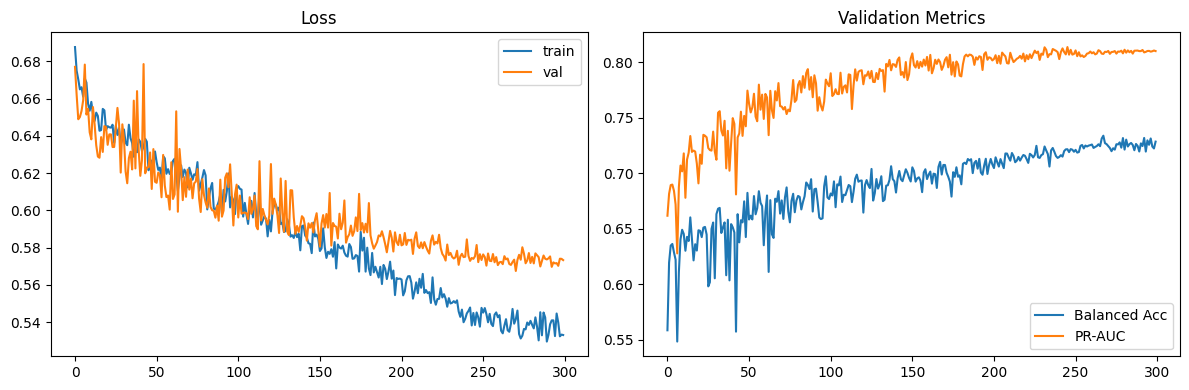

Saved classifier_head.pt and classifier_scaler.pkl


In [ ]:
# Naive training loop for a simple classifier head on top of the extracted features

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load data
data  = np.load("classifier_features.npz")
X_all = data["X"].astype(np.float32)
y_all = data["y"].astype(np.int64)

# Reduce spatial cube (N, K, K, K, C) -> (N, C) via average pool
if X_all.ndim == 5:
    X_all = X_all.mean(axis=(1, 2, 3))   # (N, C=120)

print(f"Loaded: X={X_all.shape}  cells={(y_all==1).sum()}  non_cells={(y_all==0).sum()}")

# Train / Val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Feature normalisation (fit on train only)
scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)

# Weighted sampler
class_counts = np.bincount(y_tr)
n_samples = len(y_tr)

weights_per_class = n_samples / (2.0 * class_counts)
sample_weights = weights_per_class[y_tr]

sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights.astype(np.float32)),
    num_samples=n_samples,
    replacement=True
)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=128,
    sampler=sampler
)

val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=512,
    shuffle=False
)

# Model
in_dim = X_all.shape[1]

model = nn.Sequential(
    nn.Linear(in_dim, 120),
    nn.BatchNorm1d(120),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(120, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(32, 2),
).to(device)

# Plain cross-entropy
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

n_epochs = 300

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

# Training loop
train_losses, val_losses = [], []
val_bal_accs, val_pr_aucs = [], []

best_pr_auc = -1.0
best_state  = None

for epoch in range(n_epochs):
    # ---- TRAIN ----
    model.train()
    running = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * len(yb)

    train_loss = running / len(y_tr)
    train_losses.append(train_loss)
    scheduler.step()

    # ---- VALIDATION ----
    model.eval()
    vloss = 0.0

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]

            vloss += criterion(logits, yb).item() * len(yb)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    val_loss = vloss / len(y_val)
    val_losses.append(val_loss)

    # ---- Metrics ----
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob)

    val_bal_accs.append(bal_acc)
    val_pr_aucs.append(pr_auc)

    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"train={train_loss:.4f} val={val_loss:.4f} | "
              f"bal_acc={bal_acc:.3f} PR-AUC={pr_auc:.3f}")

# Final evaluation (best checkpoint)
model.load_state_dict(best_state)
model.eval()

y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1]
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print(f"\nBest PR-AUC checkpoint: {best_pr_auc:.4f}")
print("\nClassification report (default threshold=0.5):")
print(classification_report(y_true, y_pred, digits=4))

# Optional: threshold tuning
prec, rec, thresh = precision_recall_curve(y_true, y_prob)
f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1)

best_thresh = thresh[best_idx]
print(f"\nBest threshold (F1): {best_thresh:.3f}")

y_pred_opt = (np.array(y_prob) > best_thresh).astype(int)
print("\nClassification report (optimized threshold):")
print(classification_report(y_true, y_pred_opt, digits=4))

# Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(val_bal_accs, label="Balanced Acc")
axes[1].plot(val_pr_aucs, label="PR-AUC")
axes[1].set_title("Validation Metrics")
axes[1].legend()

plt.tight_layout()
plt.show()

# Save best model + scaler
import joblib

torch.save(model.state_dict(), "classifier_head.pt")
joblib.dump(scaler, "classifier_scaler.pkl")
print("Saved classifier_head.pt and classifier_scaler.pkl")


# More realistic scenario with limited data

Loaded: X=(7467, 120)  cells=4371  non_cells=3096

Dataset-level split:
  Train   6010  cells=3318  non_cells=2692  datasets=[np.int64(649103), np.int64(657882), np.int64(659012), np.int64(695727), np.int64(802584), np.int64(817328)]
  Val      552  cells= 432  non_cells= 120  datasets=[np.int64(701121)]
  Test     905  cells= 621  non_cells= 284  datasets=[np.int64(702321)]
Epoch  10 | train=0.6536 val=0.6314 | bal_acc=0.527 PR-AUC=0.851
Epoch  20 | train=0.6465 val=0.5915 | bal_acc=0.627 PR-AUC=0.884
Epoch  30 | train=0.6394 val=0.6083 | bal_acc=0.616 PR-AUC=0.861
Epoch  40 | train=0.6314 val=0.5885 | bal_acc=0.614 PR-AUC=0.875
Epoch  50 | train=0.6151 val=0.6372 | bal_acc=0.568 PR-AUC=0.851
Epoch  60 | train=0.6225 val=0.5873 | bal_acc=0.573 PR-AUC=0.865
Epoch  70 | train=0.6188 val=0.5899 | bal_acc=0.590 PR-AUC=0.861
Epoch  80 | train=0.6113 val=0.5836 | bal_acc=0.602 PR-AUC=0.870
Epoch  90 | train=0.6141 val=0.5930 | bal_acc=0.616 PR-AUC=0.868
Epoch 100 | train=0.6070 val=0.5770 |

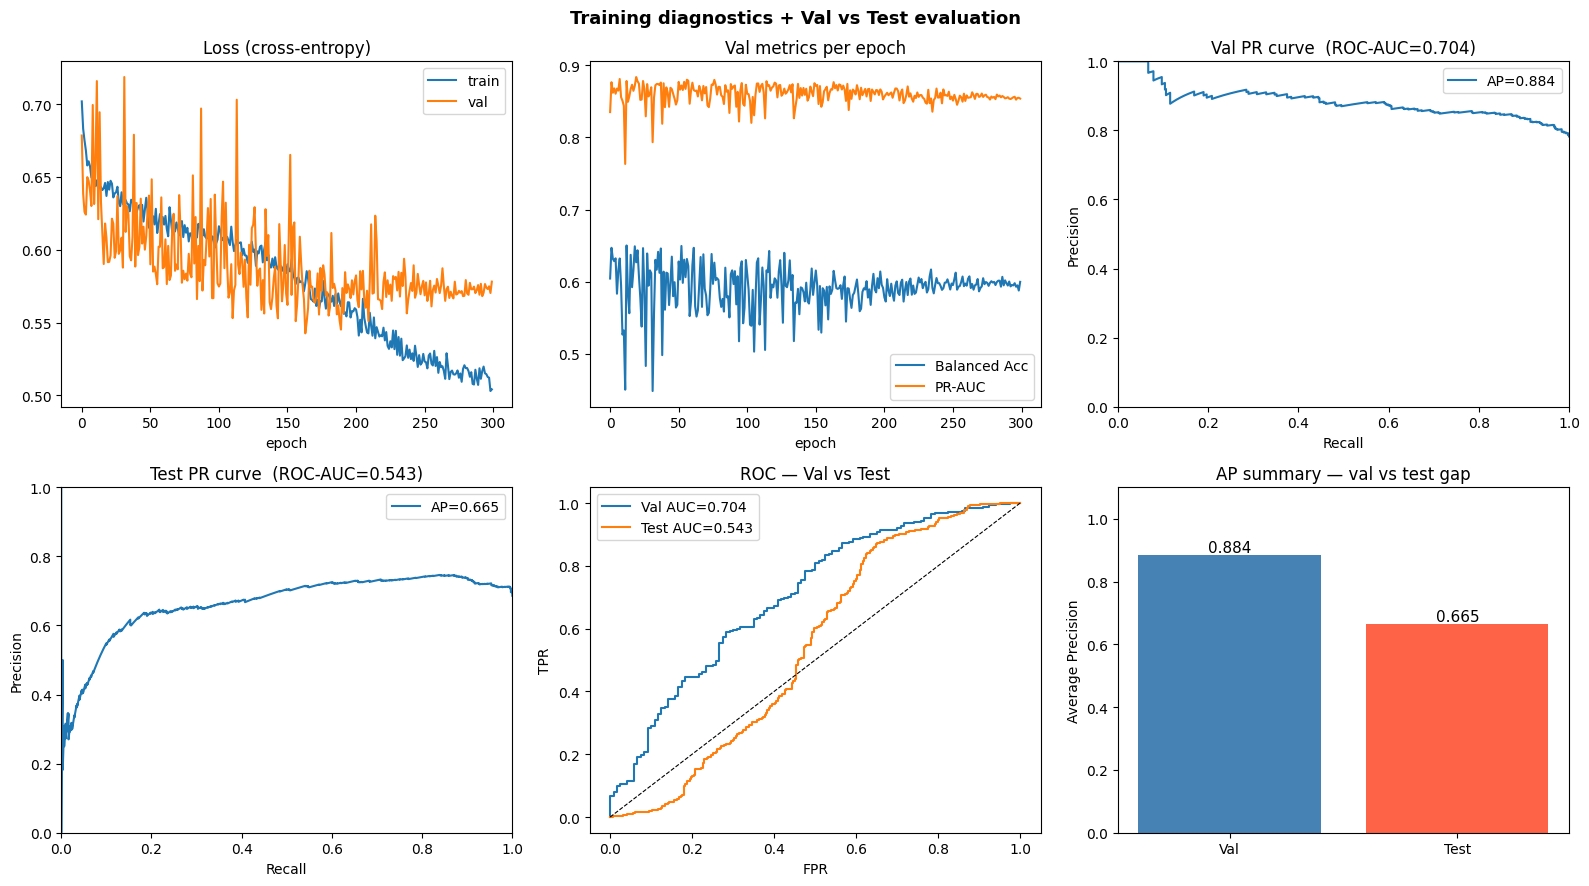


Saved classifier_head.pt, classifier_scaler.pkl, best_threshold.npy
Val AP=0.8838  Test AP=0.6648  Gap=0.2190


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

device = "cuda" if torch.cuda.is_available() else "cpu"

# Loading precomputed features and labels
# we could add data augmentation and generate a big dataset
data = np.load("classifier_features.npz")
X_all = data["X"].astype(np.float32)
y_all = data["y"].astype(np.int64)
dataset_ids = data["dataset_ids"]

# Reduce spatial cube (N, K, K, K, C) → (N, C) via average pool
if X_all.ndim == 5:
    X_all = X_all.mean(axis=(1, 2, 3))   # (N, C=120)

print(f"Loaded: X={X_all.shape}  cells={(y_all==1).sum()}  non_cells={(y_all==0).sum()}")

# Dataset-level split
# Held-out test: two datasets with good class coverage from different time periods.
#   702321 (Nov 2023)     — 621 cells /  284 non-cells
# Validation: one dataset used only for checkpoint selection (no tuning on test).
#   701121 (Nov 2023)     — 432 cells /  120 non-cells

# Train: everything else (649103, 657882, 659012, 695727, 817328)
TEST_DATASETS = {702321}
VAL_DATASETS  = {701121}

train_mask = ~np.isin(dataset_ids, list(TEST_DATASETS | VAL_DATASETS))
val_mask   =  np.isin(dataset_ids, list(VAL_DATASETS))
test_mask  =  np.isin(dataset_ids, list(TEST_DATASETS))

X_tr, y_tr   = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask],   y_all[val_mask]
X_te, y_te   = X_all[test_mask],  y_all[test_mask]

print("\nDataset-level split:")
print(f"  Train  {X_tr.shape[0]:5d}  cells={(y_tr==1).sum():4d}  non_cells={(y_tr==0).sum():4d}  "
      f"datasets={sorted(set(dataset_ids[train_mask]))}")
print(f"  Val    {X_val.shape[0]:5d}  cells={(y_val==1).sum():4d}  non_cells={(y_val==0).sum():4d}  "
      f"datasets={sorted(set(dataset_ids[val_mask]))}")
print(f"  Test   {X_te.shape[0]:5d}  cells={(y_te==1).sum():4d}  non_cells={(y_te==0).sum():4d}  "
      f"datasets={sorted(set(dataset_ids[test_mask]))}")

# Feature normalisation (fit on train only)
scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr).astype(np.float32)

# Note: Apply scaling statistics from training on val and test
X_val = scaler.transform(X_val).astype(np.float32)
X_te  = scaler.transform(X_te).astype(np.float32)

# Weighted sampler for class imbalance in train
class_counts = np.bincount(y_tr)
weights_per_class = len(y_tr) / (2.0 * class_counts)
sample_weights = weights_per_class[y_tr]

sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights.astype(np.float32)),
    num_samples=len(y_tr),
    replacement=True,
)

# Dataloaders
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=128, sampler=sampler,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=512, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
    batch_size=512, shuffle=False,
)

# Model
in_dim = X_all.shape[1]

# Note Camilo:
# Using leaky relu and dropout 0.5 to help regularize, prevent overfitting
# and handle died neurons
model = nn.Sequential(
    nn.Linear(in_dim, 120),
    nn.BatchNorm1d(120),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(120, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.LeakyReLU(),
    nn.Dropout(0.1),

    nn.Linear(32, 2),
).to(device)

# Note Camilo
# Adding label smoothing to avoid overconfidence
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# Training loop
n_epochs = 300
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
train_losses, val_losses = [], []
val_bal_accs, val_pr_aucs = [], []

best_pr_auc = -1.0
best_state  = None

for epoch in range(n_epochs):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(yb)
    train_losses.append(running / len(y_tr))
    scheduler.step()

    model.eval()
    vloss, y_true, y_pred, y_prob = 0.0, [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            vloss += criterion(logits, yb).item() * len(yb)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    val_losses.append(vloss / len(y_val))
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc  = average_precision_score(y_true, y_prob)
    val_bal_accs.append(bal_acc)
    val_pr_aucs.append(pr_auc)

    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train={train_losses[-1]:.4f} val={val_losses[-1]:.4f} | "
              f"bal_acc={bal_acc:.3f} PR-AUC={pr_auc:.3f}")

# Reload best checkpoint
model.load_state_dict(best_state)
model.eval()

def _eval_loader(loader):
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

val_true,  val_pred,  val_prob  = _eval_loader(val_loader)
test_true, test_pred, test_prob = _eval_loader(test_loader)

# Threshold tuning on val (never on test)
prec_v, rec_v, thresh_v = precision_recall_curve(val_true, val_prob)
f1_v  = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
best_thresh = thresh_v[np.argmax(f1_v)]

print(f"\nBest val PR-AUC (checkpoint): {best_pr_auc:.4f}")
print(f"Best threshold (tuned on val, F1): {best_thresh:.3f}")

for name, yt, yp_raw, yp_th in [
    ("Val  (threshold=0.5)",        val_true,  val_pred,                              None),
    ("Val  (threshold tuned)",      val_true,  (val_prob  > best_thresh).astype(int), None),
    ("Test (threshold=0.5)",        test_true, test_pred,                             None),
    ("Test (threshold tuned on val)", test_true, (test_prob > best_thresh).astype(int), None),
]:
    pred = yp_th if yp_th is not None else yp_raw
    print(f"\n── {name} ──")
    print(classification_report(yt, pred, digits=4))

# Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Training diagnostics + Val vs Test evaluation", fontsize=13, fontweight="bold")

# Row 0: training curves
axes[0, 0].plot(train_losses, label="train")
axes[0, 0].plot(val_losses,   label="val")
axes[0, 0].set_title("Loss (cross-entropy)")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].legend()

axes[0, 1].plot(val_bal_accs,  label="Balanced Acc")
axes[0, 1].plot(val_pr_aucs,   label="PR-AUC")
axes[0, 1].set_title("Val metrics per epoch")
axes[0, 1].set_xlabel("epoch"); axes[0, 1].legend()

# Val vs Test PR curves
for ax, yt, yp, split in [
    (axes[0, 2], val_true,  val_prob,  "Val"),
    (axes[1, 0], test_true, test_prob, "Test"),
]:
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = auc(fpr, tpr)
    ax.plot(rec, prec, lw=1.5, label=f"AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{split} PR curve  (ROC-AUC={roc_auc:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend()

# ROC overlay
for yt, yp, label in [
    (val_true,  val_prob,  "Val"),
    (test_true, test_prob, "Test"),
]:
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[1, 1].plot(fpr, tpr, lw=1.5, label=f"{label} AUC={auc(fpr,tpr):.3f}")
axes[1, 1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1, 1].set_xlabel("FPR"); axes[1, 1].set_ylabel("TPR")
axes[1, 1].set_title("ROC — Val vs Test"); axes[1, 1].legend()

# PR-AUC gap bar
splits = ["Val", "Test"]
ap_vals = [average_precision_score(val_true,  val_prob),
           average_precision_score(test_true, test_prob)]
bar_colors = ["steelblue", "tomato"]
axes[1, 2].bar(splits, ap_vals, color=bar_colors)
for i, v in enumerate(ap_vals):
    axes[1, 2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=11)
axes[1, 2].set_ylim(0, 1.1)
axes[1, 2].set_title("AP summary — val vs test gap")
axes[1, 2].set_ylabel("Average Precision")

plt.tight_layout()
plt.show()

# Save
torch.save(model.state_dict(), "classifier_head.pt")
joblib.dump(scaler, "classifier_scaler.pkl")
np.save("best_threshold.npy", best_thresh)
print("\nSaved classifier_head.pt, classifier_scaler.pkl, best_threshold.npy")
print(f"Val AP={ap_vals[0]:.4f}  Test AP={ap_vals[1]:.4f}  "
      f"Gap={ap_vals[0]-ap_vals[1]:.4f}")


In [ ]:
# # Coodinate alignment check
# import matplotlib.pyplot as plt
# import numpy as np
# import torch
# from functools import partial

# from mesoscale_cell_classification_head.pipeline import _load_box_batch
# from mesoscale_cell_classification_head.feature_extraction import run_batch
# from mesoscale_cell_classification_head.preprocessing import apply_transform

# # Pick the first box that has ≥3 annotated cells (not just ≥5 total points)
# def _count_cells(ids):
#     return sum(1 for pt in cell_zyx_ds[ids] if label_lookup_ds.get(tuple(pt), -1) == 1)

# demo_box_idx = next(
#     (i for i, ids in enumerate(box_cells_ids) if _count_cells(ids) >= 3),
#     None,
# )
# if demo_box_idx is None:
#     raise RuntimeError("No box with ≥3 annotated cells found — check label_lookup_ds")

# preprocessing_func = partial(apply_transform, transform=val_transform)

# batch_chunks, batch_points, batch_starts = _load_box_batch(
#     [demo_box_idx], boxes, box_cells_ids, cell_zyx_ds, loaded_zarr,
#     overlap=cfg["overlap"], box_dim=cfg["box_dim"],
# )
# chunk     = batch_chunks[0]   # (D, H, W)
# local_pts = batch_points[0]   # (N, 3) in local chunk frame

# # Recover global coords and label each point using cell 05abb3e1's lookup
# _, padded_start = batch_starts[0]
# global_pts_diag = local_pts + padded_start   # (N, 3) global ZYX
# pt_labels_diag  = np.array(
#     [label_lookup_ds.get(tuple(pt), -1) for pt in global_pts_diag],
#     dtype=np.int8,
# )
# cell_mask_diag = pt_labels_diag == 1

# print(f"Chunk shape : {chunk.shape}")
# print(f"Points in box: {len(local_pts)}  "
#       f"(cells: {cell_mask_diag.sum()}, non-cells: {(pt_labels_diag == 0).sum()}, "
#       f"unlabelled: {(pt_labels_diag < 0).sum()})")
# print(f"Cell local positions (first 6):\n{local_pts[cell_mask_diag][:6]}")

# with torch.no_grad():
#     fm = run_batch([chunk], reconstruction_model, device,
#                    preprocessing_func=preprocessing_func)[0].float().cpu()

# C, Fz, Fy, Fx = fm.shape
# patch_size = cfg["patch_size"]
# fm_mag = torch.norm(fm, dim=0).numpy()  # (Fz, Fy, Fx)

# feat_pts = np.clip(
#     np.round(local_pts / patch_size).astype(int),
#     0, [Fz - 1, Fy - 1, Fx - 1],
# )

# # ── slice positions: median of *cell* coords in each axis ───────────────────
# cell_local = local_pts[cell_mask_diag]
# slice_z = int(np.median(cell_local[:, 0]))
# slice_y = int(np.median(cell_local[:, 1]))
# slice_x = int(np.median(cell_local[:, 2]))
# feat_slice_z = int(np.median(feat_pts[cell_mask_diag, 0]))
# feat_slice_y = int(np.median(feat_pts[cell_mask_diag, 1]))
# feat_slice_x = int(np.median(feat_pts[cell_mask_diag, 2]))
# half = 15  # ±15 image voxels ≈ one full patch width; increases visible dots

# print(f"\nSlice positions — image: Z={slice_z}, Y={slice_y}, X={slice_x}")
# print(f"Slice positions — feat:  Z={feat_slice_z}, Y={feat_slice_y}, X={feat_slice_x}")

# # ── 3 pairs of (image slice, feature slice) ─────────────────────────────────
# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# fig.suptitle(
#     f"Box {demo_box_idx} — coordinate alignment check (cells only, slices not MIPs)\n"
#     "Top: image slice through median cell Z/Y/X.  "
#     "Bottom: feature-map ‖f‖ at corresponding patch slice.\n"
#     f"Red ● = cells within ±{half} voxels of the slice plane.",
#     fontsize=9,
# )

# # --- Z slice (looking from above, shows Y-X plane) --------------------------
# near_z = (np.abs(local_pts[:, 0] - slice_z) <= half) & cell_mask_diag
# ax = axes[0, 0]
# ax.imshow(chunk[slice_z], cmap="gray", origin="upper", aspect="auto")
# ax.scatter(local_pts[near_z, 2], local_pts[near_z, 1],
#            c="red", s=30, linewidths=0, alpha=0.9)
# ax.set_title(f"Image Z-slice @ z={slice_z}  (Y×X plane)  n={near_z.sum()}", fontsize=9)
# ax.set_xlabel("X"); ax.set_ylabel("Y")

# ax2 = axes[1, 0]
# ax2.imshow(fm_mag[feat_slice_z], cmap="inferno", origin="upper", aspect="auto")
# ax2.scatter(feat_pts[near_z, 2], feat_pts[near_z, 1],
#             c="cyan", s=50, marker="s", linewidths=0.5, edgecolors="white", alpha=0.9)
# ax2.set_title(f"Feature Z-slice @ fz={feat_slice_z}  (Fy×Fx patch plane)", fontsize=9)
# ax2.set_xlabel("patch X"); ax2.set_ylabel("patch Y")

# # --- Y slice (front view, shows Z-X plane) ----------------------------------
# near_y = (np.abs(local_pts[:, 1] - slice_y) <= half) & cell_mask_diag
# ax = axes[0, 1]
# ax.imshow(chunk[:, slice_y, :], cmap="gray", origin="upper", aspect="auto")
# ax.scatter(local_pts[near_y, 2], local_pts[near_y, 0],
#            c="red", s=30, linewidths=0, alpha=0.9)
# ax.set_title(f"Image Y-slice @ y={slice_y}  (Z×X plane)  n={near_y.sum()}", fontsize=9)
# ax.set_xlabel("X"); ax.set_ylabel("Z")

# ax2 = axes[1, 1]
# ax2.imshow(fm_mag[:, feat_slice_y, :], cmap="inferno", origin="upper", aspect="auto")
# ax2.scatter(feat_pts[near_y, 2], feat_pts[near_y, 0],
#             c="cyan", s=50, marker="s", linewidths=0.5, edgecolors="white", alpha=0.9)
# ax2.set_title(f"Feature Y-slice @ fy={feat_slice_y}  (Fz×Fx patch plane)", fontsize=9)
# ax2.set_xlabel("patch X"); ax2.set_ylabel("patch Z")

# # --- X slice (side view, shows Z-Y plane) -----------------------------------
# near_x = (np.abs(local_pts[:, 2] - slice_x) <= half) & cell_mask_diag
# ax = axes[0, 2]
# ax.imshow(chunk[:, :, slice_x], cmap="gray", origin="upper", aspect="auto")
# ax.scatter(local_pts[near_x, 1], local_pts[near_x, 0],
#            c="red", s=30, linewidths=0, alpha=0.9)
# ax.set_title(f"Image X-slice @ x={slice_x}  (Z×Y plane)  n={near_x.sum()}", fontsize=9)
# ax.set_xlabel("Y"); ax.set_ylabel("Z")

# ax2 = axes[1, 2]
# ax2.imshow(fm_mag[:, :, feat_slice_x], cmap="inferno", origin="upper", aspect="auto")
# ax2.scatter(feat_pts[near_x, 1], feat_pts[near_x, 0],
#             c="cyan", s=50, marker="s", linewidths=0.5, edgecolors="white", alpha=0.9)
# ax2.set_title(f"Feature X-slice @ fx={feat_slice_x}  (Fz×Fy patch plane)", fontsize=9)
# ax2.set_xlabel("patch Y"); ax2.set_ylabel("patch Z")

# plt.tight_layout()
# plt.show()

# # ── numeric check ────────────────────────────────────────────────────────────
# patch_centers = (feat_pts + 0.5) * patch_size
# offsets = np.abs(local_pts[cell_mask_diag] - patch_centers[cell_mask_diag])
# print(f"\nOffset from patch centre (voxels, cells only): "
#       f"mean={offsets.mean():.2f}  max={offsets.max():.2f}  "
#       f"(max possible = {patch_size/2:.1f})")
